# Project - Electricity Demand Forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import random

In [2]:
# TIMESTAMP_INTEGRITY_SKILL: Validate CSV before loading
import duckdb, sys
CSV_PATH = r"C:\Users\tusha\Desktop\ML\project_elec_demand\electricity demand dataset.csv"

# Step 1: Check for malformed timestamps via try_cast
con = duckdb.connect()
invalid = con.execute(f"""
    SELECT count(*) FROM read_csv_auto('{CSV_PATH}', strict_mode=false)
    WHERE try_cast(
        strptime("Timestamp", '%d-%b-%y') + INTERVAL (CAST(COALESCE(hour, 0) AS INTEGER)) HOUR
        AS TIMESTAMP
    ) IS NULL
""").fetchone()[0]

# Step 2: Abort if any malformed rows
if invalid > 0:
    bad = con.execute(f"""
        SELECT "Timestamp", hour FROM read_csv_auto('{CSV_PATH}', strict_mode=false)
        WHERE try_cast(
            strptime("Timestamp", '%d-%b-%y') + INTERVAL (CAST(COALESCE(hour, 0) AS INTEGER)) HOUR
            AS TIMESTAMP
        ) IS NULL
    """).fetchdf()
    print(f"ERROR: {invalid} malformed timestamp(s) found. Aborting.")
    print(bad.to_string())
    con.close()
    sys.exit(1)
else:
    print(f"All timestamps valid. Proceeding.")
con.close()

All timestamps valid. Proceeding.


In [3]:
import duckdb
con = duckdb.connect(r"C:\Users\tusha\Desktop\ML\project_elec_demand\electricity_data.db")
data = con.execute("""
    SELECT
        timestamp AS Timestamp,
        hour, dayofweek, month, year, dayofyear,
        temperature AS Temperature,
        humidity AS Humidity,
        demand AS Demand
    FROM demand_records
    ORDER BY timestamp
""").fetchdf()
con.close()

In [4]:
data

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,2020-01-01 00:00:00,0,2,1,2020,1,3.000000,61.288952,2457.119873
1,2020-01-01 01:00:00,1,2,1,2020,1,3.000000,52.873703,2269.904785
2,2020-01-01 02:00:00,2,2,1,2020,1,4.244482,36.341782,2215.640381
3,2020-01-01 03:00:00,3,2,1,2020,1,3.000000,72.629379,2174.232422
4,2020-01-01 04:00:00,4,2,1,2020,1,3.881208,90.582443,2472.453125
...,...,...,...,...,...,...,...,...,...
43832,2024-12-31 19:00:00,19,1,12,2024,366,3.956838,43.287163,4689.692871
43833,2024-12-31 20:00:00,20,1,12,2024,366,3.118824,51.705757,4331.249023
43834,2024-12-31 21:00:00,21,1,12,2024,366,3.000000,40.565918,4015.979980
43835,2024-12-31 22:00:00,22,1,12,2024,366,3.000000,51.998108,3353.241699


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43837 entries, 0 to 43836
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    43837 non-null  datetime64[us]
 1   hour         43837 non-null  int32         
 2   dayofweek    43832 non-null  Int32         
 3   month        43833 non-null  Int32         
 4   year         43836 non-null  Int32         
 5   dayofyear    43836 non-null  Int32         
 6   Temperature  43834 non-null  float32       
 7   Humidity     43831 non-null  float32       
 8   Demand       43834 non-null  float32       
dtypes: Int32(4), datetime64[us](1), float32(3), int32(1)
memory usage: 1.8 MB


In [6]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43837 entries, 0 to 43836
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    43837 non-null  datetime64[us]
 1   hour         43837 non-null  int32         
 2   dayofweek    43832 non-null  Int32         
 3   month        43833 non-null  Int32         
 4   year         43836 non-null  Int32         
 5   dayofyear    43836 non-null  Int32         
 6   Temperature  43834 non-null  float32       
 7   Humidity     43831 non-null  float32       
 8   Demand       43834 non-null  float32       
dtypes: Int32(4), datetime64[us](1), float32(3), int32(1)
memory usage: 1.8 MB


In [8]:
data = data.set_index('Timestamp')

In [9]:
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,3.000000,61.288952,2457.119873
2020-01-01 01:00:00,1,2,1,2020,1,3.000000,52.873703,2269.904785
2020-01-01 02:00:00,2,2,1,2020,1,4.244482,36.341782,2215.640381
2020-01-01 03:00:00,3,2,1,2020,1,3.000000,72.629379,2174.232422
2020-01-01 04:00:00,4,2,1,2020,1,3.881208,90.582443,2472.453125
...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,3.956838,43.287163,4689.692871
2024-12-31 20:00:00,20,1,12,2024,366,3.118824,51.705757,4331.249023
2024-12-31 21:00:00,21,1,12,2024,366,3.000000,40.565918,4015.979980


In [10]:
data[['Temperature', 'Humidity', 'Demand']].describe()

,Temperature,Humidity,Demand
count,43834.000000,43831.000000,43834.000000
mean,25.068024,59.903534,5000.761230
std,12.821754,18.343288,1412.511475
min,3.000000,20.000000,1611.953979
25%,15.210299,46.242317,4015.679688
50%,25.004030,59.987484,5012.995117
75%,34.740940,73.798264,6000.786621
max,50.000000,95.000000,11910.705078


In [11]:
data.isnull().sum()

hour           0
dayofweek      5
month          4
year           1
dayofyear      1
Temperature    3
Humidity       6
Demand         3
dtype: int64

In [12]:

data[data.isna().any(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2021-12-13 23:00:00,23,0,12,2021,<NA>,3.000000,75.457130,3225.225830
2021-12-14 14:00:00,14,1,12,2021,348,15.403995,74.011559,NaN
2022-06-17 13:00:00,13,4,6,2022,168,NaN,43.171391,7196.201172
2022-06-17 17:00:00,17,4,<NA>,2022,168,37.115635,37.554844,7696.863281
2022-06-17 18:00:00,18,4,6,2022,168,39.886471,NaN,7830.425293
2022-06-17 21:00:00,21,<NA>,6,2022,168,28.471495,54.964100,6408.288574
2022-06-18 05:00:00,5,5,6,2022,169,38.349174,58.285812,NaN
2023-08-31 00:00:00,0,<NA>,8,2023,243,22.705122,81.691818,4307.377930
2023-08-31 05:00:00,5,3,<NA>,2023,243,29.081791,81.270821,5181.232910


In [13]:
data[data.isna().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,


In [14]:
data = data.dropna(how = 'all')
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,3.000000,61.288952,2457.119873
2020-01-01 01:00:00,1,2,1,2020,1,3.000000,52.873703,2269.904785
2020-01-01 02:00:00,2,2,1,2020,1,4.244482,36.341782,2215.640381
2020-01-01 03:00:00,3,2,1,2020,1,3.000000,72.629379,2174.232422
2020-01-01 04:00:00,4,2,1,2020,1,3.881208,90.582443,2472.453125
...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,3.956838,43.287163,4689.692871
2024-12-31 20:00:00,20,1,12,2024,366,3.118824,51.705757,4331.249023
2024-12-31 21:00:00,21,1,12,2024,366,3.000000,40.565918,4015.979980


In [15]:
data[data.isna().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,


In [16]:
# Check for Missing Values

data.isnull().sum()

hour           0
dayofweek      5
month          4
year           1
dayofyear      1
Temperature    3
Humidity       6
Demand         3
dtype: int64

In [17]:
data[['hour', 'dayofweek', 'month', 'year', 'dayofyear']] = data[['hour', 'dayofweek', 'month', 'year', 'dayofyear']].ffill()

In [18]:
data[['Temperature', 'Humidity']] = data[['Temperature', 'Humidity']].bfill()

In [19]:

data['Demand'] = data['Demand'].interpolate(method = 'time')

In [20]:

data.isnull().sum()

hour           0
dayofweek      0
month          0
year           0
dayofyear      0
Temperature    0
Humidity       0
Demand         0
dtype: int64

In [21]:

data.shape

(43837, 8)

In [22]:
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,3.000000,61.288952,2457.119873
2020-01-01 01:00:00,1,2,1,2020,1,3.000000,52.873703,2269.904785
2020-01-01 02:00:00,2,2,1,2020,1,4.244482,36.341782,2215.640381
2020-01-01 03:00:00,3,2,1,2020,1,3.000000,72.629379,2174.232422
2020-01-01 04:00:00,4,2,1,2020,1,3.881208,90.582443,2472.453125
...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,3.956838,43.287163,4689.692871
2024-12-31 20:00:00,20,1,12,2024,366,3.118824,51.705757,4331.249023
2024-12-31 21:00:00,21,1,12,2024,366,3.000000,40.565918,4015.979980


In [23]:
data.insert(5, 'quarter', data.index.quarter)

In [24]:
data

,hour,dayofweek,month,year,dayofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,1,3.000000,61.288952,2457.119873
2020-01-01 01:00:00,1,2,1,2020,1,1,3.000000,52.873703,2269.904785
2020-01-01 02:00:00,2,2,1,2020,1,1,4.244482,36.341782,2215.640381
2020-01-01 03:00:00,3,2,1,2020,1,1,3.000000,72.629379,2174.232422
2020-01-01 04:00:00,4,2,1,2020,1,1,3.881208,90.582443,2472.453125
...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,4,3.956838,43.287163,4689.692871
2024-12-31 20:00:00,20,1,12,2024,366,4,3.118824,51.705757,4331.249023
2024-12-31 21:00:00,21,1,12,2024,366,4,3.000000,40.565918,4015.979980


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43837 entries, 2020-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43837 non-null  int32  
 1   dayofweek    43837 non-null  Int32  
 2   month        43837 non-null  Int32  
 3   year         43837 non-null  Int32  
 4   dayofyear    43837 non-null  Int32  
 5   quarter      43837 non-null  int32  
 6   Temperature  43837 non-null  float32
 7   Humidity     43837 non-null  float32
 8   Demand       43837 non-null  float32
dtypes: Int32(4), float32(3), int32(2)
memory usage: 2.0 MB


In [26]:
data[['hour', 'dayofweek', 'month','year', 'dayofyear']] = data[['hour', 'dayofweek', 'month','year', 'dayofyear']].astype(int)

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43837 entries, 2020-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43837 non-null  int64  
 1   dayofweek    43837 non-null  int64  
 2   month        43837 non-null  int64  
 3   year         43837 non-null  int64  
 4   dayofyear    43837 non-null  int64  
 5   quarter      43837 non-null  int32  
 6   Temperature  43837 non-null  float32
 7   Humidity     43837 non-null  float32
 8   Demand       43837 non-null  float32
dtypes: float32(3), int32(1), int64(5)
memory usage: 2.7 MB


In [28]:
data

,hour,dayofweek,month,year,dayofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,1,3.000000,61.288952,2457.119873
2020-01-01 01:00:00,1,2,1,2020,1,1,3.000000,52.873703,2269.904785
2020-01-01 02:00:00,2,2,1,2020,1,1,4.244482,36.341782,2215.640381
2020-01-01 03:00:00,3,2,1,2020,1,1,3.000000,72.629379,2174.232422
2020-01-01 04:00:00,4,2,1,2020,1,1,3.881208,90.582443,2472.453125
...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,4,3.956838,43.287163,4689.692871
2024-12-31 20:00:00,20,1,12,2024,366,4,3.118824,51.705757,4331.249023
2024-12-31 21:00:00,21,1,12,2024,366,4,3.000000,40.565918,4015.979980


In [29]:
data.insert(5, 'weekofyear', data.index.isocalendar().week.astype(int))

In [30]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,1,1,3.000000,61.288952,2457.119873
2020-01-01 01:00:00,1,2,1,2020,1,1,1,3.000000,52.873703,2269.904785
2020-01-01 02:00:00,2,2,1,2020,1,1,1,4.244482,36.341782,2215.640381
2020-01-01 03:00:00,3,2,1,2020,1,1,1,3.000000,72.629379,2174.232422
2020-01-01 04:00:00,4,2,1,2020,1,1,1,3.881208,90.582443,2472.453125
...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,1,4,3.956838,43.287163,4689.692871
2024-12-31 20:00:00,20,1,12,2024,366,1,4,3.118824,51.705757,4331.249023
2024-12-31 21:00:00,21,1,12,2024,366,1,4,3.000000,40.565918,4015.979980


In [31]:
data.tail(50)

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2024-12-29 22:00:00,22,6,12,2024,364,52,4,3.000000,70.021729,2929.747314
2024-12-29 23:00:00,23,6,12,2024,364,52,4,3.000000,52.836010,2668.369873
2024-12-30 00:00:00,0,0,12,2024,365,1,4,3.000000,65.892960,2699.075439
2024-12-30 01:00:00,1,0,12,2024,365,1,4,3.000000,72.128006,2644.045898
2024-12-30 02:00:00,2,0,12,2024,365,1,4,3.000000,68.631805,2206.527344
2024-12-30 03:00:00,3,0,12,2024,365,1,4,5.018972,78.981499,2414.881104
2024-12-30 04:00:00,4,0,12,2024,365,1,4,3.000000,70.592476,2473.705322
2024-12-30 05:00:00,5,0,12,2024,365,1,4,7.835546,74.624100,3291.585449
2024-12-30 06:00:00,6,0,12,2024,365,1,4,11.118482,68.974586,4120.280762


In [32]:
data.insert(7, 'is_weekend', data.index.dayofweek.isin([5,6]))

In [33]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,1,1,False,3.000000,61.288952,2457.119873
2020-01-01 01:00:00,1,2,1,2020,1,1,1,False,3.000000,52.873703,2269.904785
2020-01-01 02:00:00,2,2,1,2020,1,1,1,False,4.244482,36.341782,2215.640381
2020-01-01 03:00:00,3,2,1,2020,1,1,1,False,3.000000,72.629379,2174.232422
2020-01-01 04:00:00,4,2,1,2020,1,1,1,False,3.881208,90.582443,2472.453125
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,1,4,False,3.956838,43.287163,4689.692871
2024-12-31 20:00:00,20,1,12,2024,366,1,4,False,3.118824,51.705757,4331.249023
2024-12-31 21:00:00,21,1,12,2024,366,1,4,False,3.000000,40.565918,4015.979980


In [34]:
data['is_weekend'] = data['is_weekend'].astype(int)

In [35]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,1,1,0,3.000000,61.288952,2457.119873
2020-01-01 01:00:00,1,2,1,2020,1,1,1,0,3.000000,52.873703,2269.904785
2020-01-01 02:00:00,2,2,1,2020,1,1,1,0,4.244482,36.341782,2215.640381
2020-01-01 03:00:00,3,2,1,2020,1,1,1,0,3.000000,72.629379,2174.232422
2020-01-01 04:00:00,4,2,1,2020,1,1,1,0,3.881208,90.582443,2472.453125
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,1,4,0,3.956838,43.287163,4689.692871
2024-12-31 20:00:00,20,1,12,2024,366,1,4,0,3.118824,51.705757,4331.249023
2024-12-31 21:00:00,21,1,12,2024,366,1,4,0,3.000000,40.565918,4015.979980


In [36]:

data[data['is_weekend'] == 1]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-04 00:00:00,0,5,1,2020,4,1,1,1,3.000000,60.955364,2067.352783
2020-01-04 01:00:00,1,5,1,2020,4,1,1,1,3.000000,66.494072,2138.504639
2020-01-04 02:00:00,2,5,1,2020,4,1,1,1,3.000000,56.398197,1880.418701
2020-01-04 03:00:00,3,5,1,2020,4,1,1,1,4.474526,60.603500,2005.823853
2020-01-04 04:00:00,4,5,1,2020,4,1,1,1,7.738184,65.808823,2203.720459
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29 19:00:00,19,6,12,2024,364,52,4,1,7.077721,46.341324,4304.049316
2024-12-29 20:00:00,20,6,12,2024,364,52,4,1,3.000000,69.641624,4146.583984
2024-12-29 21:00:00,21,6,12,2024,364,52,4,1,3.723222,46.751732,3366.641113


In [37]:
import holidays

In [38]:
data['Holidays'] = holidays.IN(years = data.year)

In [39]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Holidays
Timestamp,,,,,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,1,1,0,3.000000,61.288952,2457.119873,NaN
2020-01-01 01:00:00,1,2,1,2020,1,1,1,0,3.000000,52.873703,2269.904785,NaN
2020-01-01 02:00:00,2,2,1,2020,1,1,1,0,4.244482,36.341782,2215.640381,NaN
2020-01-01 03:00:00,3,2,1,2020,1,1,1,0,3.000000,72.629379,2174.232422,NaN
2020-01-01 04:00:00,4,2,1,2020,1,1,1,0,3.881208,90.582443,2472.453125,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,1,4,0,3.956838,43.287163,4689.692871,NaN
2024-12-31 20:00:00,20,1,12,2024,366,1,4,0,3.118824,51.705757,4331.249023,NaN
2024-12-31 21:00:00,21,1,12,2024,366,1,4,0,3.000000,40.565918,4015.979980,NaN


In [40]:
data.Holidays.value_counts()

Holidays
Republic Day          5
Maha Shivaratri       5
Mahavir Jayanti       5
Good Friday           5
Buddha Purnima        5
Id-ul-Fitr            5
Bakrid                5
Janmashtami           5
Independence Day      5
Muharram              5
Gandhi Jayanti        5
Dussehra              5
Milad-un-Nabi         5
Diwali                5
Guru Nanak Jayanti    5
Christmas             5
Name: count, dtype: int64

In [41]:
data = data.drop('Holidays', axis=1)

In [42]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,1,1,0,3.000000,61.288952,2457.119873
2020-01-01 01:00:00,1,2,1,2020,1,1,1,0,3.000000,52.873703,2269.904785
2020-01-01 02:00:00,2,2,1,2020,1,1,1,0,4.244482,36.341782,2215.640381
2020-01-01 03:00:00,3,2,1,2020,1,1,1,0,3.000000,72.629379,2174.232422
2020-01-01 04:00:00,4,2,1,2020,1,1,1,0,3.881208,90.582443,2472.453125
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,1,4,0,3.956838,43.287163,4689.692871
2024-12-31 20:00:00,20,1,12,2024,366,1,4,0,3.118824,51.705757,4331.249023
2024-12-31 21:00:00,21,1,12,2024,366,1,4,0,3.000000,40.565918,4015.979980


In [43]:
def create_features(df, db_path=r"C:\Users\tusha\Desktop\ML\project_elec_demand\electricity_data.db"):
    """Add 24h lag, 168h lag, 24h rolling mean & std via DuckDB window functions."""
    import duckdb
    try:
        con = duckdb.connect(db_path)
        result = con.execute("""
            SELECT
                timestamp,
                LAG(demand, 24) OVER (ORDER BY timestamp) AS Demand_lag_24hr,
                LAG(demand, 168) OVER (ORDER BY timestamp) AS demand_lag_168hr,
                AVG(demand) OVER (ORDER BY timestamp ROWS BETWEEN 23 PRECEDING AND CURRENT ROW) AS demand_rolling_mean_24hr,
                STDDEV(demand) OVER (ORDER BY timestamp ROWS BETWEEN 23 PRECEDING AND CURRENT ROW) AS demand_rolling_std_24hr
            FROM demand_records
            ORDER BY timestamp
        """).fetchdf()
        con.close()
    except duckdb.Error as e:
        raise ConnectionError(f"DuckDB connection failed: {e}") from e
    df['Demand_lag_24hr'] = result['Demand_lag_24hr'].values
    df['demand_lag_168hr'] = result['demand_lag_168hr'].values
    df['demand_rolling_mean_24hr'] = result['demand_rolling_mean_24hr'].values
    df['demand_rolling_std_24hr'] = result['demand_rolling_std_24hr'].values
    return df

data = create_features(data)

In [44]:
# handled by create_features() above

In [45]:
data.head(50)

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,1,1,0,3.000000,61.288952,2457.119873,NaN,NaN,2457.119873,NaN
2020-01-01 01:00:00,1,2,1,2020,1,1,1,0,3.000000,52.873703,2269.904785,NaN,NaN,2363.512329,132.381058
2020-01-01 02:00:00,2,2,1,2020,1,1,1,0,4.244482,36.341782,2215.640381,NaN,NaN,2314.221680,126.692844
2020-01-01 03:00:00,3,2,1,2020,1,1,1,0,3.000000,72.629379,2174.232422,NaN,NaN,2279.224365,124.899823
2020-01-01 04:00:00,4,2,1,2020,1,1,1,0,3.881208,90.582443,2472.453125,NaN,NaN,2317.870117,138.446542
2020-01-01 05:00:00,5,2,1,2020,1,1,1,0,10.822571,67.753433,3104.845459,NaN,NaN,2449.032674,344.319117
2020-01-01 06:00:00,6,2,1,2020,1,1,1,0,6.306674,94.912590,3759.476807,NaN,NaN,2636.238979,586.617236
2020-01-01 07:00:00,7,2,1,2020,1,1,1,0,7.464640,74.456863,4114.485840,NaN,NaN,2821.019836,753.731740
2020-01-01 08:00:00,8,2,1,2020,1,1,1,0,14.746877,66.725006,4575.159668,NaN,NaN,3015.924262,915.962450


In [46]:
data.iloc[160:200]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-07 16:00:00,16,1,1,2020,7,2,1,0,14.016616,37.637753,4587.785156,4733.816406,NaN,3850.341644,967.346061
2020-01-07 17:00:00,17,1,1,2020,7,2,1,0,6.736632,54.734905,4833.704102,4796.039551,NaN,3851.911001,968.976181
2020-01-07 18:00:00,18,1,1,2020,7,2,1,0,17.782434,49.297649,5400.257812,4791.519043,NaN,3877.275116,1002.043906
2020-01-07 19:00:00,19,1,1,2020,7,2,1,0,3.000000,37.696671,4424.535156,4492.166016,NaN,3874.457163,1000.333160
2020-01-07 20:00:00,20,1,1,2020,7,2,1,0,7.116704,46.152199,4279.454102,4398.302246,NaN,3869.505157,997.918447
2020-01-07 21:00:00,21,1,1,2020,7,2,1,0,5.158936,44.385460,3768.807129,3705.698486,NaN,3872.134684,997.551127
2020-01-07 22:00:00,22,1,1,2020,7,2,1,0,3.000000,46.821529,2924.189453,3211.918457,NaN,3860.145976,1007.509951
2020-01-07 23:00:00,23,1,1,2020,7,2,1,0,3.000000,44.708096,2657.653076,2857.968750,NaN,3851.799489,1016.958659
2020-01-08 00:00:00,0,2,1,2020,8,2,1,0,3.000000,47.891594,2363.060059,2216.875977,2457.119873,3857.890493,1007.130940


In [47]:
# handled by create_features() above

In [48]:
# handled by create_features() above

In [49]:
data.head(27)

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,1,1,0,3.000000,61.288952,2457.119873,NaN,NaN,2457.119873,NaN
2020-01-01 01:00:00,1,2,1,2020,1,1,1,0,3.000000,52.873703,2269.904785,NaN,NaN,2363.512329,132.381058
2020-01-01 02:00:00,2,2,1,2020,1,1,1,0,4.244482,36.341782,2215.640381,NaN,NaN,2314.221680,126.692844
2020-01-01 03:00:00,3,2,1,2020,1,1,1,0,3.000000,72.629379,2174.232422,NaN,NaN,2279.224365,124.899823
2020-01-01 04:00:00,4,2,1,2020,1,1,1,0,3.881208,90.582443,2472.453125,NaN,NaN,2317.870117,138.446542
2020-01-01 05:00:00,5,2,1,2020,1,1,1,0,10.822571,67.753433,3104.845459,NaN,NaN,2449.032674,344.319117
2020-01-01 06:00:00,6,2,1,2020,1,1,1,0,6.306674,94.912590,3759.476807,NaN,NaN,2636.238979,586.617236
2020-01-01 07:00:00,7,2,1,2020,1,1,1,0,7.464640,74.456863,4114.485840,NaN,NaN,2821.019836,753.731740
2020-01-01 08:00:00,8,2,1,2020,1,1,1,0,14.746877,66.725006,4575.159668,NaN,NaN,3015.924262,915.962450


In [50]:
data = data.dropna()
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-08 00:00:00,0,2,1,2020,8,2,1,0,3.000000,47.891594,2363.060059,2216.875977,2457.119873,3857.890493,1007.130940
2020-01-08 01:00:00,1,2,1,2020,8,2,1,0,4.433666,61.209728,2282.558838,2400.102539,2269.904785,3852.992839,1014.785075
2020-01-08 02:00:00,2,2,1,2020,8,2,1,0,5.000529,63.868618,2193.324219,2493.107422,2215.640381,3840.501872,1033.916324
2020-01-08 03:00:00,3,2,1,2020,8,2,1,0,4.253477,44.603210,2208.724609,2241.451660,2174.232422,3839.138245,1036.136197
2020-01-08 04:00:00,4,2,1,2020,8,2,1,0,5.966043,85.921005,2402.611084,2406.160889,2472.453125,3838.990336,1036.349880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,1,4,0,3.956838,43.287163,4689.692871,5102.077148,5105.730469,4039.969940,976.961259
2024-12-31 20:00:00,20,1,12,2024,366,1,4,0,3.118824,51.705757,4331.249023,4187.844238,4673.672363,4045.945140,978.342559
2024-12-31 21:00:00,21,1,12,2024,366,1,4,0,3.000000,40.565918,4015.979980,3859.260742,3856.359131,4052.475108,977.565059


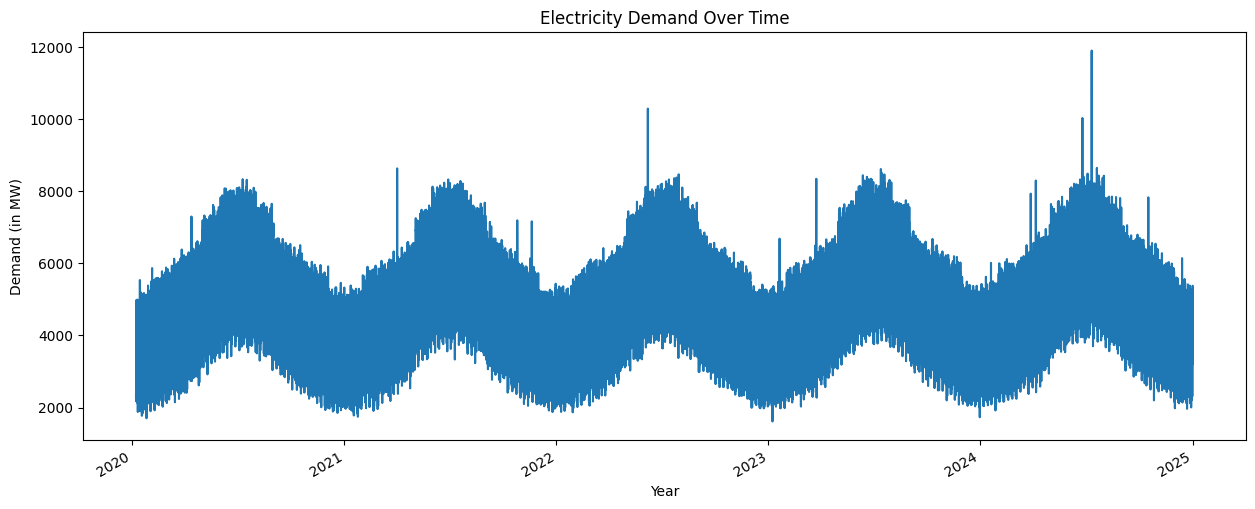

In [51]:
# Plot raw demand over time

data['Demand'].plot(figsize =(15,6), title = "Electricity Demand Over Time")
plt.xlabel("Year")                          # naming for x-axis
plt.ylabel("Demand (in MW)")                # naming for y-axis  
                   
plt.show()

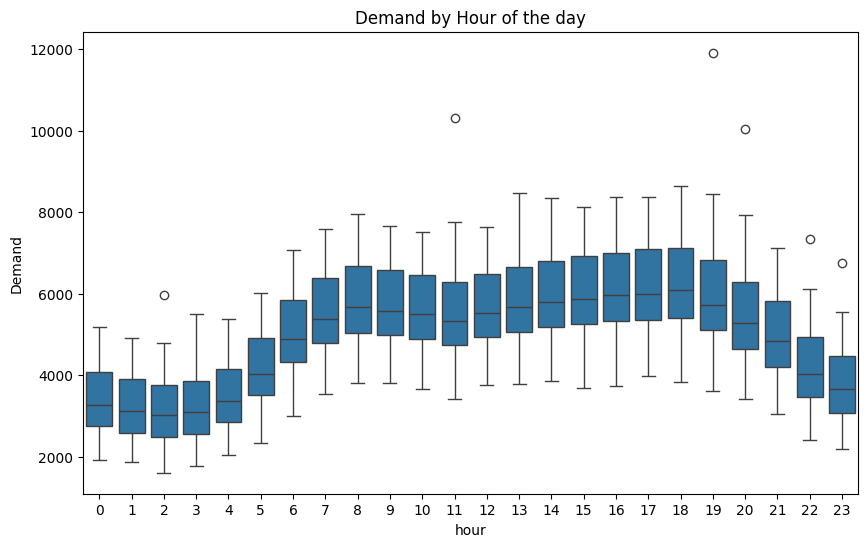

In [52]:
# demand by hour of day

plt.figure(figsize = (10,6))
sns.boxplot(data = data, x = 'hour', y = 'Demand')
plt.title("Demand by Hour of the day");

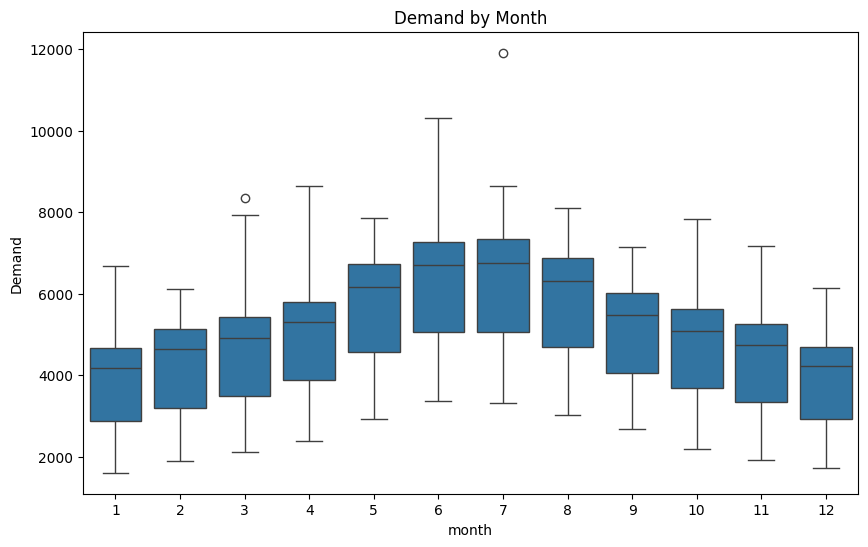

In [53]:
# demand by month

plt.figure(figsize=(10,6))
sns.boxplot(data = data, x = 'month', y = 'Demand')
plt.title("Demand by Month")
plt.show()

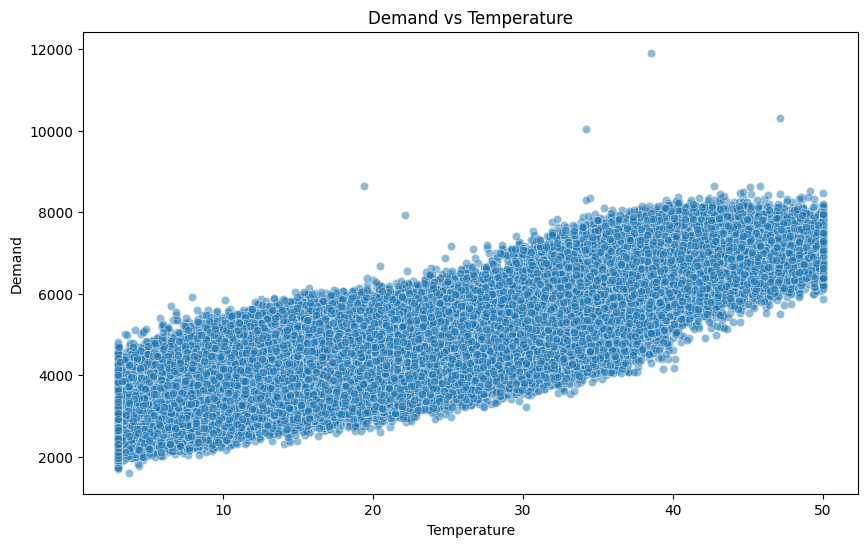

In [54]:


plt.figure(figsize=(10,6))
sns.scatterplot(data = data, x = 'Temperature', y = 'Demand', alpha = 0.5)  #alpha - to adjust the tranparency of points
plt.title("Demand vs Temperature")
plt.show()

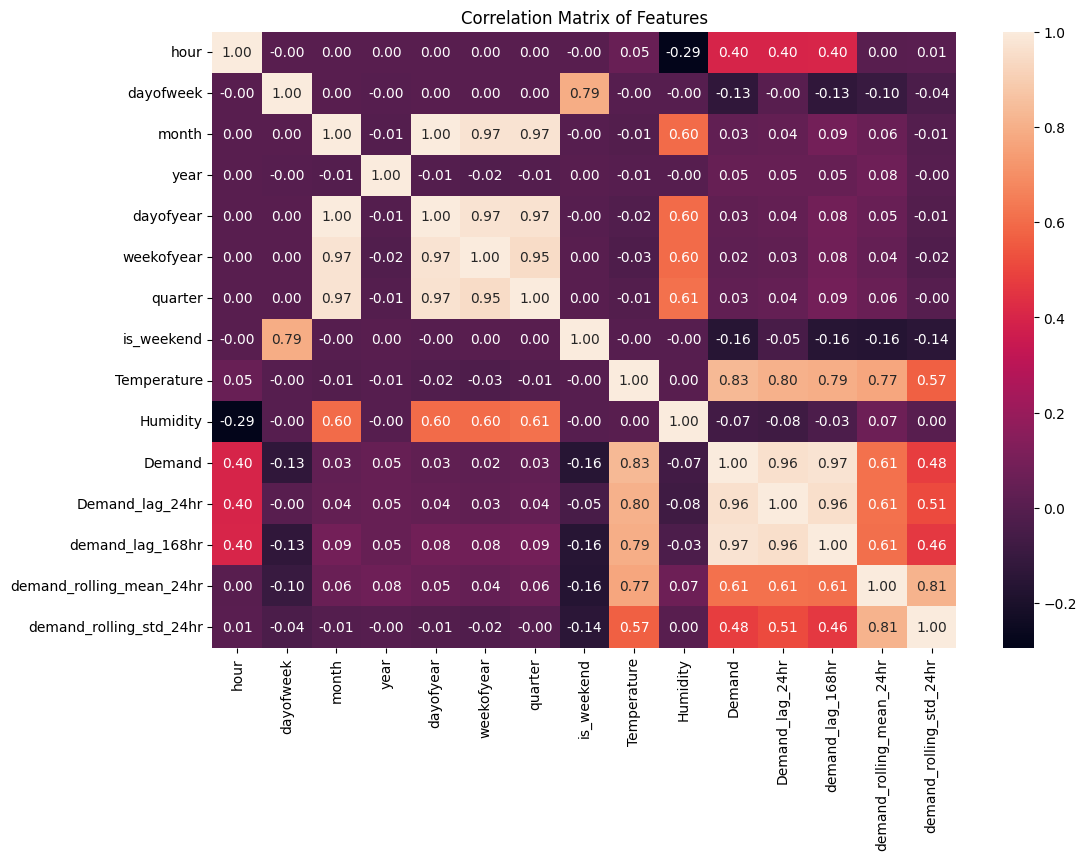

In [55]:
# Correlation Matrix and Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot = True, fmt=".2f") # anoot=True : to show the numbers , fmt : to adjust decimals
plt.title("Correlation Matrix of Features")
plt.show()

In [56]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-08 00:00:00,0,2,1,2020,8,2,1,0,3.000000,47.891594,2363.060059,2216.875977,2457.119873,3857.890493,1007.130940
2020-01-08 01:00:00,1,2,1,2020,8,2,1,0,4.433666,61.209728,2282.558838,2400.102539,2269.904785,3852.992839,1014.785075
2020-01-08 02:00:00,2,2,1,2020,8,2,1,0,5.000529,63.868618,2193.324219,2493.107422,2215.640381,3840.501872,1033.916324
2020-01-08 03:00:00,3,2,1,2020,8,2,1,0,4.253477,44.603210,2208.724609,2241.451660,2174.232422,3839.138245,1036.136197
2020-01-08 04:00:00,4,2,1,2020,8,2,1,0,5.966043,85.921005,2402.611084,2406.160889,2472.453125,3838.990336,1036.349880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,1,4,0,3.956838,43.287163,4689.692871,5102.077148,5105.730469,4039.969940,976.961259
2024-12-31 20:00:00,20,1,12,2024,366,1,4,0,3.118824,51.705757,4331.249023,4187.844238,4673.672363,4045.945140,978.342559
2024-12-31 21:00:00,21,1,12,2024,366,1,4,0,3.000000,40.565918,4015.979980,3859.260742,3856.359131,4052.475108,977.565059


In [57]:
Y = data.Demand                       

In [58]:
X = data.drop('Demand', axis=1)         

In [59]:
print(Y)         

Timestamp
2020-01-08 00:00:00    2363.060059
2020-01-08 01:00:00    2282.558838
2020-01-08 02:00:00    2193.324219
2020-01-08 03:00:00    2208.724609
2020-01-08 04:00:00    2402.611084
                          ...     
2024-12-31 19:00:00    4689.692871
2024-12-31 20:00:00    4331.249023
2024-12-31 21:00:00    4015.979980
2024-12-31 22:00:00    3353.241699
2024-12-31 23:00:00    3219.023438
Name: Demand, Length: 43663, dtype: float32


In [60]:
X                  

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2020-01-08 00:00:00,0,2,1,2020,8,2,1,0,3.000000,47.891594,2216.875977,2457.119873,3857.890493,1007.130940
2020-01-08 01:00:00,1,2,1,2020,8,2,1,0,4.433666,61.209728,2400.102539,2269.904785,3852.992839,1014.785075
2020-01-08 02:00:00,2,2,1,2020,8,2,1,0,5.000529,63.868618,2493.107422,2215.640381,3840.501872,1033.916324
2020-01-08 03:00:00,3,2,1,2020,8,2,1,0,4.253477,44.603210,2241.451660,2174.232422,3839.138245,1036.136197
2020-01-08 04:00:00,4,2,1,2020,8,2,1,0,5.966043,85.921005,2406.160889,2472.453125,3838.990336,1036.349880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,1,4,0,3.956838,43.287163,5102.077148,5105.730469,4039.969940,976.961259
2024-12-31 20:00:00,20,1,12,2024,366,1,4,0,3.118824,51.705757,4187.844238,4673.672363,4045.945140,978.342559
2024-12-31 21:00:00,21,1,12,2024,366,1,4,0,3.000000,40.565918,3859.260742,3856.359131,4052.475108,977.565059


In [61]:
X_train = X.loc[ : '2023-12-31']                 

In [62]:
X_train                                        

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2020-01-08 00:00:00,0,2,1,2020,8,2,1,0,3.000000,47.891594,2216.875977,2457.119873,3857.890493,1007.130940
2020-01-08 01:00:00,1,2,1,2020,8,2,1,0,4.433666,61.209728,2400.102539,2269.904785,3852.992839,1014.785075
2020-01-08 02:00:00,2,2,1,2020,8,2,1,0,5.000529,63.868618,2493.107422,2215.640381,3840.501872,1033.916324
2020-01-08 03:00:00,3,2,1,2020,8,2,1,0,4.253477,44.603210,2241.451660,2174.232422,3839.138245,1036.136197
2020-01-08 04:00:00,4,2,1,2020,8,2,1,0,5.966043,85.921005,2406.160889,2472.453125,3838.990336,1036.349880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,19,6,12,2023,365,52,4,1,6.721774,46.627262,3894.908203,3840.654785,3597.790593,879.089462
2023-12-31 20:00:00,20,6,12,2023,365,52,4,1,7.557696,58.505013,3797.287842,4122.218750,3599.126928,879.430221
2023-12-31 21:00:00,21,6,12,2023,365,52,4,1,3.000000,48.001080,3280.602295,3307.887207,3604.785558,877.726858


In [63]:
Y_train = Y.loc[ : '2023-12-31' ]            

In [64]:
Y_train                                      

Timestamp
2020-01-08 00:00:00    2363.060059
2020-01-08 01:00:00    2282.558838
2020-01-08 02:00:00    2193.324219
2020-01-08 03:00:00    2208.724609
2020-01-08 04:00:00    2402.611084
                          ...     
2023-12-31 19:00:00    4185.721680
2023-12-31 20:00:00    3829.359863
2023-12-31 21:00:00    3416.409424
2023-12-31 22:00:00    3188.144043
2023-12-31 23:00:00    2631.860840
Name: Demand, Length: 34882, dtype: float32

In [65]:
X_test = X.loc[ '2024-01-01' : ]             

In [66]:
X_test                                      

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2024-01-01 00:00:00,0,0,1,2024,1,1,1,0,3.000000,65.297043,2373.967529,2752.003174,3626.185654,856.204497
2024-01-01 01:00:00,1,0,1,2024,1,1,1,0,3.000000,69.068657,2328.972900,2419.747559,3640.380417,836.357274
2024-01-01 02:00:00,2,0,1,2024,1,1,1,0,3.000000,80.885368,1729.176147,2292.833984,3669.813863,776.458052
2024-01-01 03:00:00,3,0,1,2024,1,1,1,0,7.788675,66.501526,2257.337402,2507.704590,3685.801626,749.595460
2024-01-01 04:00:00,4,0,1,2024,1,1,1,0,6.607828,57.858109,2516.948975,2690.933350,3692.926656,738.736309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,19,1,12,2024,366,1,4,0,3.956838,43.287163,5102.077148,5105.730469,4039.969940,976.961259
2024-12-31 20:00:00,20,1,12,2024,366,1,4,0,3.118824,51.705757,4187.844238,4673.672363,4045.945140,978.342559
2024-12-31 21:00:00,21,1,12,2024,366,1,4,0,3.000000,40.565918,3859.260742,3856.359131,4052.475108,977.565059


In [67]:
Y_test = Y.loc[ '2024-01-01' : ]                      

In [68]:
Y_test                                                

Timestamp
2024-01-01 00:00:00    2720.605957
2024-01-01 01:00:00    2669.647217
2024-01-01 02:00:00    2435.578857
2024-01-01 03:00:00    2641.043701
2024-01-01 04:00:00    2687.949707
                          ...     
2024-12-31 19:00:00    4689.692871
2024-12-31 20:00:00    4331.249023
2024-12-31 21:00:00    4015.979980
2024-12-31 22:00:00    3353.241699
2024-12-31 23:00:00    3219.023438
Name: Demand, Length: 8781, dtype: float32

In [69]:
print(X_train.shape)                   
print(Y_train.shape)

(34882, 14)
(34882,)


In [70]:
print(X_test.shape)
print(Y_test.shape)

(8781, 14)
(8781,)


# XGBoost

In [71]:
from xgboost import XGBRegressor    
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [72]:
model_xgb = XGBRegressor(n_estimators = 1000,                
                         early_stopping_rounds = 50,
                         learning_rate = 0.01,
                         random_state = 42,
                         objective = 'reg:squarederror' )

In [73]:
model_xgb.fit(X_train, Y_train, eval_set = [(X_train, Y_train), (X_test, Y_test)], verbose = False)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


In [74]:
predictions_xgb = model_xgb.predict(X_test)

In [75]:
rmse_xgb = np.sqrt(mean_squared_error(Y_test, predictions_xgb))

mae_xgb = mean_absolute_error(Y_test, predictions_xgb )

In [76]:
print('XGBoost RMSE:',  rmse_xgb)
print('XGBoost MAE:' ,  mae_xgb)

XGBoost RMSE: 173.6542002083451
XGBoost MAE: 122.84677124023438


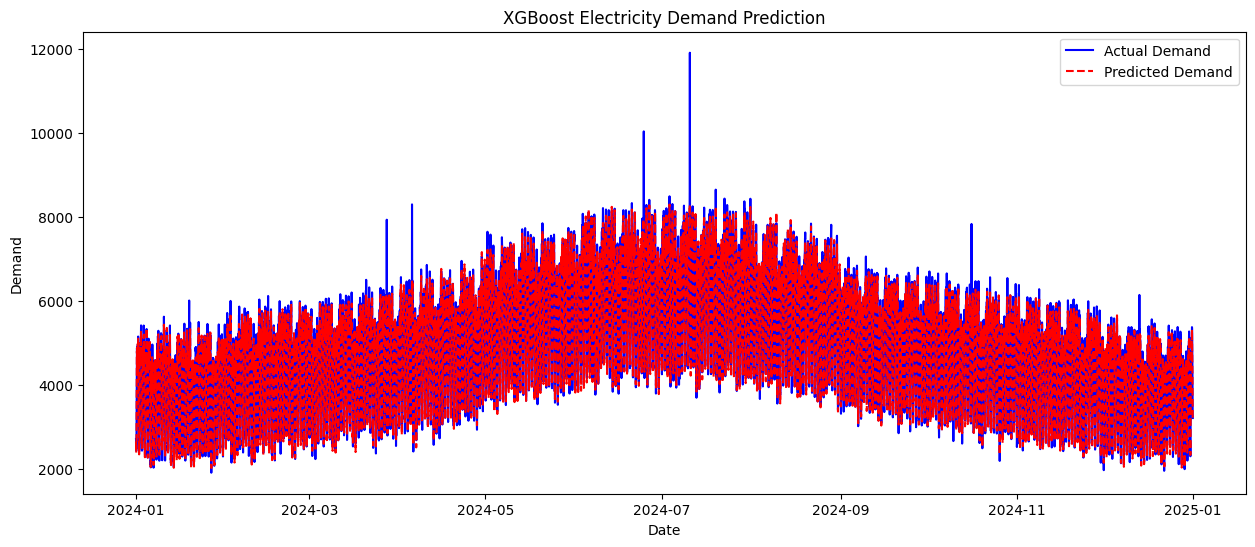

In [77]:
# Visulaize the Predictions

plt.figure(figsize = (15,6))
plt.plot(Y_test.index, Y_test, label = 'Actual Demand', color = 'Blue')
plt.plot(Y_test.index, predictions_xgb, label = 'Predicted Demand', color = 'Red', linestyle='--')
plt.title('XGBoost Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()

plt.show()

In [78]:
import joblib

joblib.dump(model_xgb, 'electricity_xgb_prediction_model.pkl')

['electricity_xgb_prediction_model.pkl']

In [79]:
loaded_model = joblib.load('electricity_xgb_prediction_model.pkl')


In [80]:
loaded_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


In [81]:
model = joblib.load('electricity_xgb_prediction_model.pkl')

sample_input = pd.DataFrame({
    'hour':[18],
    'dayofweek':[4],
    'month':[7],
    'year':[2025],
    'dayofyear':[200],
    'weekofyear':[29],
    'quarter':[3],
    'is_weekend':[0],
    'Temperature':[32],
    'Humidity':[60],
    'Demand_lag_24hr':[420],
    'demand_lag_168hr':[410],
    'demand_rolling_mean_24hr':[415],
    'demand_rolling_std_24hr':[12]
})

prediction = model.predict(sample_input)

print("Predicted Electricity Demand:", prediction[0])

Predicted Electricity Demand: 4252.0693


In [82]:
# ====== MODEL PERFORMANCE REPORT ======
import pandas as pd
import numpy as np
import duckdb

# --- 1. Performance Metrics Table ---
mape_xgb = (np.abs(Y_test - predictions_xgb) / Y_test).mean() * 100

metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MAPE (%)'],
    'Value': [f'{rmse_xgb:.2f}', f'{mae_xgb:.2f}', f'{mape_xgb:.2f}']
})
print('=' * 50)
print('MODEL PERFORMANCE METRICS')
print('=' * 50)
print(metrics_df.to_string(index=False))
print()

# --- 2. Feature Importance Table ---
feature_names = ['hour', 'dayofweek', 'month', 'year', 'dayofyear',
                 'weekofyear', 'quarter', 'is_weekend',
                 'Temperature', 'Humidity',
                 'Demand_lag_24hr', 'demand_lag_168hr',
                 'demand_rolling_mean_24hr', 'demand_rolling_std_24hr']

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model_xgb.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
importance_df['Importance'] = importance_df['Importance'].apply(lambda x: f'{x:.4f}')

print('=' * 50)
print('FEATURE IMPORTANCE')
print('=' * 50)
print(importance_df.to_string(index=False))
print()

# --- 3. Actual vs Predicted Sample Table ---
comparison_df = pd.DataFrame({
    'Timestamp': Y_test.index[:20],
    'Actual': Y_test.values[:20],
    'Predicted': predictions_xgb[:20],
    'Error': Y_test.values[:20] - predictions_xgb[:20],
    'Error %': ((Y_test.values[:20] - predictions_xgb[:20]) / Y_test.values[:20] * 100)
})
comparison_df['Actual'] = comparison_df['Actual'].apply(lambda x: f'{x:.2f}')
comparison_df['Predicted'] = comparison_df['Predicted'].apply(lambda x: f'{x:.2f}')
comparison_df['Error'] = comparison_df['Error'].apply(lambda x: f'{x:.2f}')
comparison_df['Error %'] = comparison_df['Error %'].apply(lambda x: f'{x:.2f}%')

print('=' * 100)
print('ACTUAL vs PREDICTED (First 20 Test Samples)')
print('=' * 100)
print(comparison_df.to_string(index=False))
print()

# --- 4. Summary Statistics Table ---
summary_df = pd.DataFrame({
    'Statistic': ['Total Test Samples', 'Mean Actual', 'Mean Predicted',
                   'Std Actual', 'Std Predicted', 'Min Actual', 'Max Actual',
                   'Min Predicted', 'Max Predicted', 'Over Predictions', 'Under Predictions'],
    'Value': [
        len(Y_test),
        f'{Y_test.mean():.2f}',
        f'{predictions_xgb.mean():.2f}',
        f'{Y_test.std():.2f}',
        f'{predictions_xgb.std():.2f}',
        f'{Y_test.min():.2f}',
        f'{Y_test.max():.2f}',
        f'{predictions_xgb.min():.2f}',
        f'{predictions_xgb.max():.2f}',
        (predictions_xgb > Y_test.values).sum(),
        (predictions_xgb < Y_test.values).sum()
    ]
})

print('=' * 50)
print('PREDICTION SUMMARY STATISTICS')
print('=' * 50)
print(summary_df.to_string(index=False))
print()

# --- 5. Persist to model_reports.db ---
con = duckdb.connect(r'C:\Users\tusha\Desktop\ML\project_elec_demand\model_reports.db')
con.execute('DELETE FROM model_results WHERE model_name = ?', ['XGBoost'])
con.execute('INSERT INTO model_results (model_name, rmse, mae) VALUES (?, ?, ?)',
            ['XGBoost', float(f'{rmse_xgb:.2f}'), float(f'{mae_xgb:.2f}')])
con.execute('CREATE OR REPLACE VIEW model_performance AS '
            'SELECT count(*) AS total_predictions, '
            'avg(abs(error)) AS mae, avg(abs(mape)) AS mape, '
            'sum(CASE WHEN actual < predicted THEN 1 ELSE 0 END) AS over_predictions, '
            'sum(CASE WHEN actual > predicted THEN 1 ELSE 0 END) AS under_predictions '
            'FROM predictions')

# Insert predictions batch
preds_to_insert = [(ts, float(a), float(p), float(a-p), float(abs(a-p)/a*100))
                   for ts, a, p in zip(Y_test.index[:100], Y_test.values[:100], predictions_xgb[:100])]
con.executemany('INSERT INTO predictions (timestamp, actual, predicted, error, mape) VALUES (?, ?, ?, ?, ?)',
                preds_to_insert)
print(f'Inserted {len(preds_to_insert)} predictions into model_reports.db')
print(con.execute('SELECT * FROM model_performance').fetchdf().to_string(index=False))
con.close()
print('=' * 50)
print('END OF REPORT')
print('=' * 50)


MODEL PERFORMANCE METRICS
  Metric  Value
    RMSE 173.65
     MAE 122.85
MAPE (%)   2.57

FEATURE IMPORTANCE
                 Feature Importance
        demand_lag_168hr     0.7242
         Demand_lag_24hr     0.2186
               dayofweek     0.0117
             Temperature     0.0104
demand_rolling_mean_24hr     0.0088
                   month     0.0069
                    hour     0.0057
              weekofyear     0.0042
               dayofyear     0.0034
                    year     0.0024
 demand_rolling_std_24hr     0.0019
                Humidity     0.0018
                 quarter     0.0000
              is_weekend     0.0000

ACTUAL vs PREDICTED (First 20 Test Samples)
          Timestamp  Actual Predicted   Error Error %
2024-01-01 00:00:00 2720.61   2656.47   64.14   2.36%
2024-01-01 01:00:00 2669.65   2478.04  191.61   7.18%
2024-01-01 02:00:00 2435.58   2395.24   40.34   1.66%
2024-01-01 03:00:00 2641.04   2580.21   60.83   2.30%
2024-01-01 04:00:00 2687.95   2577.

Inserted 100 predictions into model_reports.db
 total_predictions        mae     mape  over_predictions  under_predictions
               100 101.751084 2.699655              42.0               58.0
END OF REPORT


------